In [162]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sqlite3
import seaborn as sns

In [163]:
import sqlite3
import pandas as pd
from pathlib import Path


def load_db(db_path):
    """Load runs and results tables from SQLite database."""
    db_path = Path(db_path)
    if not db_path.exists():
        raise FileNotFoundError(f"Database not found: {db_path}")
    
    with sqlite3.connect(db_path) as conn:
        runs = pd.read_sql_query("SELECT * FROM runs", conn)
        results = pd.read_sql_query("SELECT * FROM results", conn)
    
    return runs, results


def merge_runs_results(runs, results):
    """Join runs and results tables on run_id."""
    merged = results.merge(runs, on="run_id", how="left")
    return merged

tptp-provable-results.db loaded:
  Runs: 3 rows
  Results: 2211 rows
  Merged: 2211 rows


TPTP Provable Results Summary
     Engine  Gathered  Timeout  Unknown  Total
      naive       152      573       12    737
         id       199      526       12    737
priority-id       209      516       12    737


C:\Users\madel\AppData\Local\Temp\ipykernel_5768\1544350362.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='engine', y='elapsed_ms', palette='Set3', ax=axes[2], order=ENGINE_ORDER)


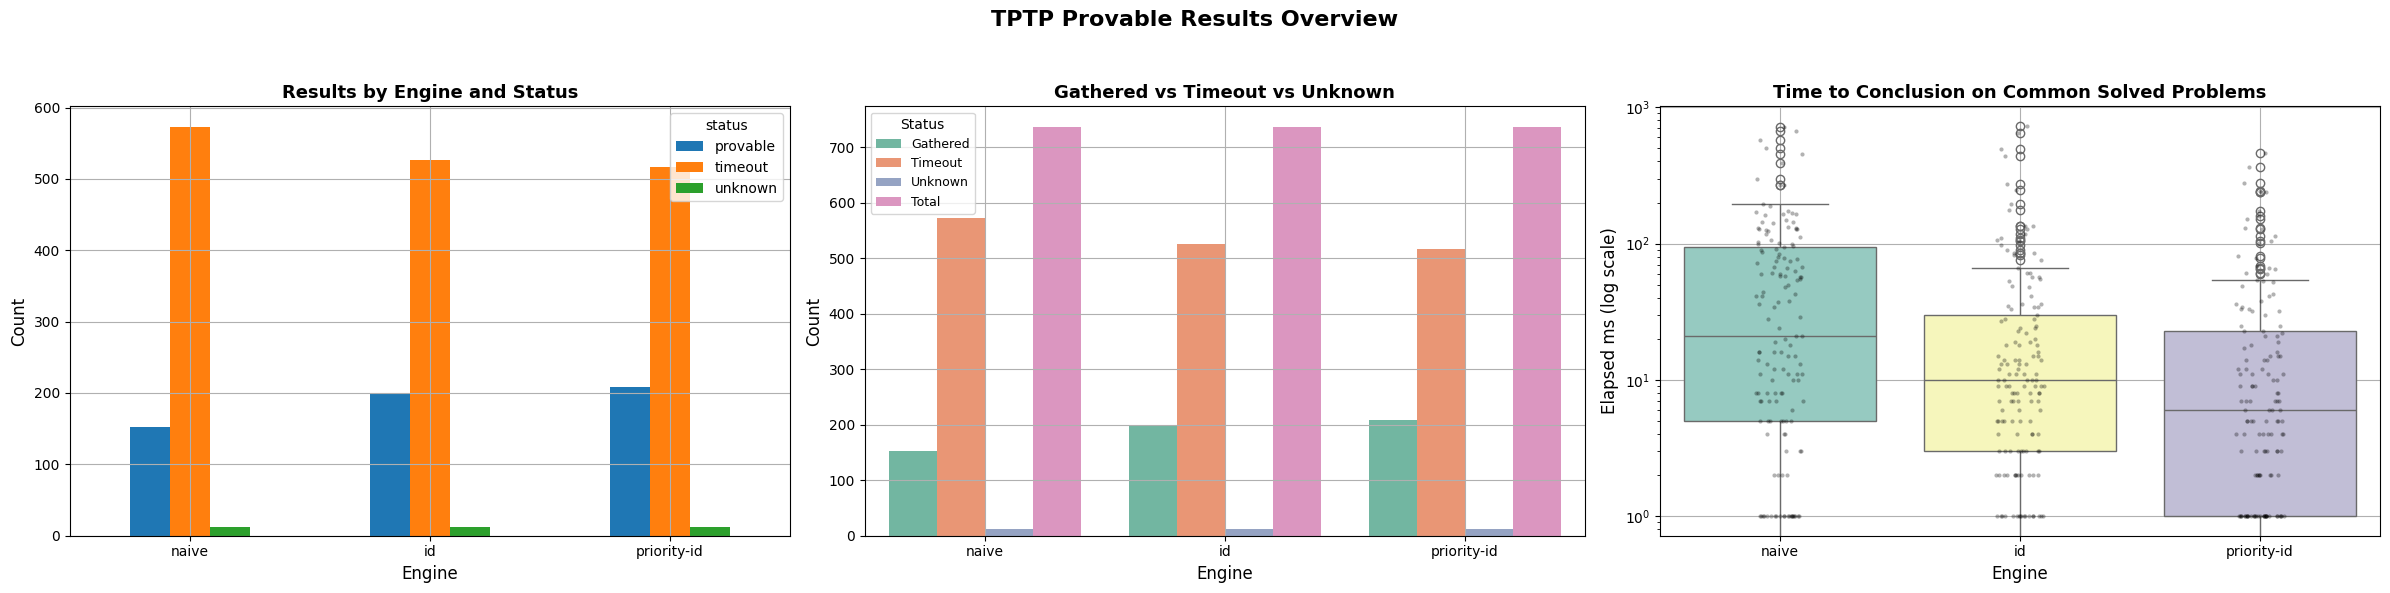


                            Output Summary                            
Output Directory: C:\Users\madel\source\repos\logic-assignment\report\figures\tabulated
Dataset: tptp_provable
Files Saved:
  - tptp_provable_engine_status_pivot.csv
  - tptp_provable_result_type_summary.csv
  - tptp_provable_common_solved_timing.csv
Figure: ../report/figures/tptp_provable_overview.svg


In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ENGINE_ORDER = ['naive', 'id', 'priority-id']


def load_and_merge_db(db_path):
    runs, results = load_db(db_path)
    merged = merge_runs_results(runs, results)
    return runs, results, merged


def print_summary_table(merged, title):
    """Print a summary table of engine counts by status."""
    status_summary = []
    for engine_name in ENGINE_ORDER:
        engine_data = merged[merged['engine'] == engine_name]
        gathered = len(engine_data[engine_data['status'].isin(['provable', 'not_provable'])])
        timeout = len(engine_data[engine_data['status'] == 'timeout'])
        unknown = len(engine_data[engine_data['status'] == 'unknown'])
        total = len(engine_data)
        status_summary.append({
            'Engine': engine_name,
            'Gathered': gathered,
            'Timeout': timeout,
            'Unknown': unknown,
            'Total': total
        })

    summary_df = pd.DataFrame(status_summary)
    print(f"\n{title}")
    print("=" * 70)
    print(summary_df.to_string(index=False))
    print("=" * 70)
    return summary_df


def _build_status_pivot(merged):
    status_summary = (
        merged[merged['engine'].isin(ENGINE_ORDER)]
        .groupby(['engine', 'status'])
        .size()
        .reset_index(name='count')
    )
    pivot = (
        status_summary.pivot(index='engine', columns='status', values='count')
        .fillna(0)
        .astype(int)
        .reindex(ENGINE_ORDER)
    )
    return pivot


def _build_result_type_summary(merged):
    status_summary = []
    for engine_name in ENGINE_ORDER:
        engine_data = merged[merged['engine'] == engine_name]
        gathered = len(engine_data[engine_data['status'].isin(['provable', 'not_provable'])])
        timeout = len(engine_data[engine_data['status'] == 'timeout'])
        unknown = len(engine_data[engine_data['status'] == 'unknown'])
        status_summary.append({
            'Engine': engine_name,
            'Gathered': gathered,
            'Timeout': timeout,
            'Unknown': unknown
        })

    return pd.DataFrame(status_summary)


def _build_common_solved_timing(merged):
    solved = merged[merged['status'].isin(['provable', 'not_provable']) & merged['engine'].isin(ENGINE_ORDER)].copy()
    solved['engine'] = pd.Categorical(solved['engine'], categories=ENGINE_ORDER, ordered=True)
    engines = solved['engine'].dropna().unique()
    if len(engines) == 0:
        return pd.DataFrame(), 'No solved rows available for timing comparison.'

    common_problems = (
        solved.groupby('problem_id')['engine'].nunique()
        .pipe(lambda counts: counts[counts == len(ENGINE_ORDER)].index)
    )
    common_solved = solved[solved['problem_id'].isin(common_problems)].copy()
    plot_df = common_solved[['problem_id', 'engine', 'elapsed_ms']].copy()
    plot_df['engine'] = pd.Categorical(plot_df['engine'], categories=ENGINE_ORDER, ordered=True)
    return plot_df, None


def _render_dataset_overview(summary_pivot, summary_df, plot_df, title, dataset_name, figure_format='pdf'):
    fig, axes = plt.subplots(1, 3, figsize=(24, 6))
    fig.suptitle(f"{title} Overview", fontsize=16, fontweight='bold')

    summary_pivot = summary_pivot.reindex(ENGINE_ORDER).fillna(0).astype(int)
    summary_pivot.plot(kind='bar', ax=axes[0])
    axes[0].grid()
    axes[0].set_title('Results by Engine and Status', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Engine', fontsize=12)
    axes[0].set_ylabel('Count', fontsize=12)
    axes[0].tick_params(axis='x', rotation=0)

    summary_df = summary_df.set_index('Engine').reindex(ENGINE_ORDER).reset_index()
    summary_df_melted = summary_df.melt(id_vars='Engine', var_name='Status', value_name='Count')
    sns.barplot(data=summary_df_melted, x='Engine', y='Count', hue='Status', ax=axes[1], palette='Set2', order=ENGINE_ORDER)
    axes[1].grid()
    axes[1].set_title('Gathered vs Timeout vs Unknown', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Engine', fontsize=12)
    axes[1].set_ylabel('Count', fontsize=12)
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].legend(title='Status', fontsize=9)

    if plot_df.empty:
        axes[2].text(0.5, 0.5, 'No solved rows available for timing comparison.', ha='center', va='center')
        axes[2].set_axis_off()
    else:
        sns.boxplot(data=plot_df, x='engine', y='elapsed_ms', palette='Set3', ax=axes[2], order=ENGINE_ORDER)
        sns.stripplot(data=plot_df, x='engine', y='elapsed_ms', color='black', alpha=0.3, size=3, ax=axes[2], order=ENGINE_ORDER)
        axes[2].set_yscale('log')
        axes[2].grid()
        axes[2].set_title('Time to Conclusion on Common Solved Problems', fontsize=13, fontweight='bold')
        axes[2].set_xlabel('Engine', fontsize=12)
        axes[2].set_ylabel('Elapsed ms (log scale)', fontsize=12)
        axes[2].tick_params(axis='x', rotation=0)

    plt.tight_layout(rect=[0, 0, 1, 0.94])
    figures_dir = Path("../report/figures")
    figures_dir.mkdir(parents=True, exist_ok=True)
    figure_path = figures_dir / f"{dataset_name}_overview.{figure_format}"
    plt.savefig(figure_path, format=figure_format)
    plt.show()


def analyze_dataset(db_path_or_df, dataset_name, title_prefix, output_dir=Path("../report/figures/tabulated"), save_csvs=None, figure_format='pdf'):
    """
    Load a database or use provided dataframe, perform full analysis, generate plots, and optionally save CSVs.
    
    Parameters:
    -----------
    db_path_or_df : str, Path, or pd.DataFrame
        Path to the SQLite database file, or a pre-loaded merged dataframe
    dataset_name : str
        Short name for the dataset (e.g., 'tptp_provable', 'bushy')
    title_prefix : str
        Descriptive prefix for titles (e.g., 'TPTP Provable Results')
    output_dir : str or Path
        Directory where CSV files will be saved
    save_csvs : iterable[str] | None
        Names of CSV outputs to save. Defaults to the plot-backed CSVs only.
        Supported values: 'summary_table', 'engine_status_pivot', 'result_type_summary', 'common_solved_timing', 'results'
    figure_format : str
        Figure format to write, for example 'svg' or 'pdf'
    """
    if save_csvs is None:
        save_csvs = {'engine_status_pivot', 'result_type_summary', 'common_solved_timing'}
    else:
        save_csvs = set(save_csvs)

    if isinstance(db_path_or_df, pd.DataFrame):
        merged = db_path_or_df.copy()
        print('Using provided dataframe:')
        print(f'  Merged: {len(merged)} rows')
    else:
        candidate_paths = [Path(f'analysis/{db_path_or_df}'), Path(db_path_or_df)]
        resolved_path = next((path for path in candidate_paths if path.exists()), candidate_paths[0])
        runs, results, merged = load_and_merge_db(resolved_path)
        print(f'{resolved_path} loaded:')
        print(f'  Runs: {len(runs)} rows')
        print(f'  Results: {len(results)} rows')
        print(f'  Merged: {len(merged)} rows')
    print()

    summary_df = print_summary_table(merged, f'{title_prefix} Summary')
    status_pivot = _build_status_pivot(merged)
    result_type_summary = _build_result_type_summary(merged)
    plot_df, timing_msg = _build_common_solved_timing(merged)
    if timing_msg:
        print(timing_msg)

    _render_dataset_overview(status_pivot, summary_df, plot_df, title_prefix, dataset_name, figure_format=figure_format)

    results_dir = Path(output_dir)
    results_dir.mkdir(parents=True, exist_ok=True)

    saved_files = []
    if 'summary_table' in save_csvs:
        summary_df.to_csv(results_dir / f"{dataset_name}_summary_table.csv", index=False)
        saved_files.append(f"{dataset_name}_summary_table.csv")
    if 'engine_status_pivot' in save_csvs:
        status_pivot.to_csv(results_dir / f"{dataset_name}_engine_status_pivot.csv")
        saved_files.append(f"{dataset_name}_engine_status_pivot.csv")
    if 'result_type_summary' in save_csvs:
        result_type_summary.to_csv(results_dir / f"{dataset_name}_result_type_summary.csv", index=False)
        saved_files.append(f"{dataset_name}_result_type_summary.csv")
    if 'common_solved_timing' in save_csvs:
        plot_df.to_csv(results_dir / f"{dataset_name}_common_solved_timing.csv", index=False)
        saved_files.append(f"{dataset_name}_common_solved_timing.csv")
    if 'results' in save_csvs:
        combined_results = summary_df.copy()
        combined_results['Dataset'] = dataset_name
        combined_results = combined_results[['Dataset', 'Engine', 'Gathered', 'Timeout', 'Unknown', 'Total']]
        combined_results = combined_results.set_index('Engine').reindex(ENGINE_ORDER).reset_index()
        combined_results.to_csv(results_dir / f"{dataset_name}_results.csv", index=False)
        saved_files.append(f"{dataset_name}_results.csv")

    print(f"\n{'Output Summary':^70}")
    print("=" * 70)
    print(f"Output Directory: {results_dir.resolve()}")
    print(f"Dataset: {dataset_name}")
    if saved_files:
        print('Files Saved:')
        for saved_file in saved_files:
            print(f'  - {saved_file}')
    else:
        print('Files Saved: none')
    print(f"Figure: ../report/figures/{dataset_name}_overview.{figure_format}")
    print("=" * 70)

    return merged, summary_df, status_pivot, result_type_summary, plot_df


# Analyze TPTP Provable
tptp_prov_merged, tptp_prov_summary, tptp_prov_status_pivot, tptp_prov_result_types, tptp_prov_timing = analyze_dataset(
    'tptp-provable-results.db',
    'tptp_provable',
    'TPTP Provable Results'
)

tptp-unprovable-results.db loaded:
  Runs: 3 rows
  Results: 453 rows
  Merged: 453 rows


TPTP Unprovable Results Summary
     Engine  Gathered  Timeout  Unknown  Total
      naive         4      143        4    151
         id         4      143        4    151
priority-id         4      142        5    151


C:\Users\madel\AppData\Local\Temp\ipykernel_5768\1544350362.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='engine', y='elapsed_ms', palette='Set3', ax=axes[2], order=ENGINE_ORDER)


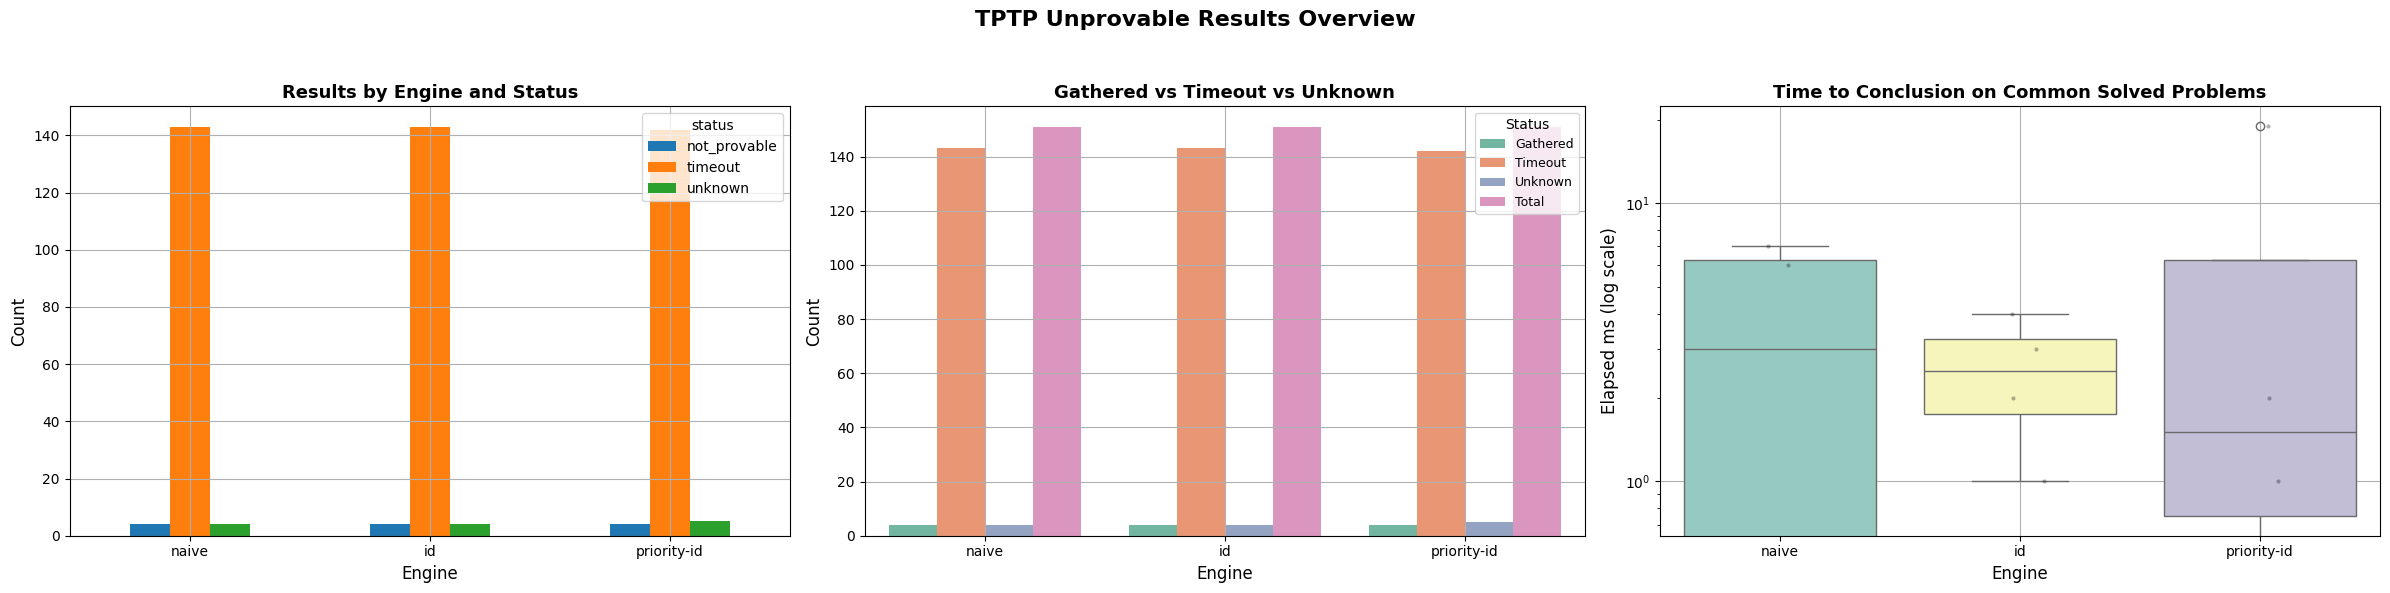


                            Output Summary                            
Output Directory: C:\Users\madel\source\repos\logic-assignment\report\figures\tabulated
Dataset: tptp_unprovable
Files Saved:
  - tptp_unprovable_engine_status_pivot.csv
  - tptp_unprovable_result_type_summary.csv
  - tptp_unprovable_common_solved_timing.csv
Figure: ../report/figures/tptp_unprovable_overview.svg


In [165]:
# Analyze TPTP Unprovable
tptp_unprv_merged, tptp_unprv_summary, tptp_unprv_status_pivot, tptp_unprv_result_types, tptp_unprv_timing = analyze_dataset(
    'tptp-unprovable-results.db',
    'tptp_unprovable',
    'TPTP Unprovable Results'
)

bushy-results.db loaded:
  Runs: 3 rows
  Results: 87 rows
  Merged: 87 rows


Bushy Results Summary
     Engine  Gathered  Timeout  Unknown  Total
      naive         1       28        0     29
         id         0        0        0      0
priority-id         5       24        0     29


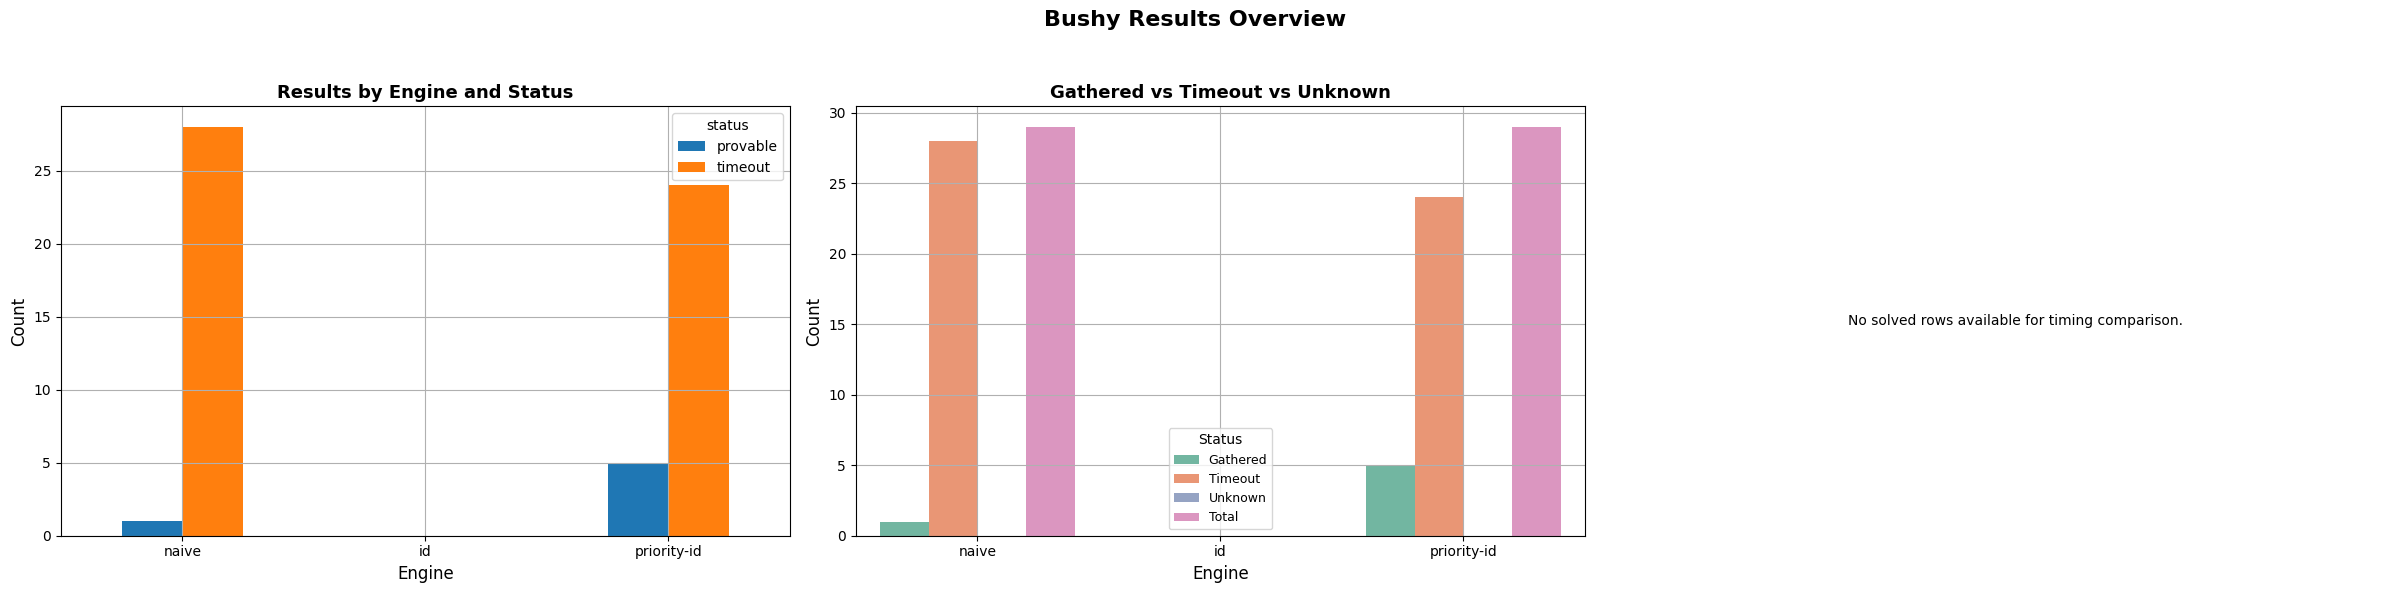


                            Output Summary                            
Output Directory: C:\Users\madel\source\repos\logic-assignment\report\figures\tabulated
Dataset: bushy
Files Saved:
  - bushy_engine_status_pivot.csv
  - bushy_result_type_summary.csv
  - bushy_common_solved_timing.csv
Figure: ../report/figures/bushy_overview.svg


In [166]:
# Analyze Bushy
bushy_merged, bushy_summary, bushy_status_pivot, bushy_result_types, bushy_timing = analyze_dataset(
    'bushy-results.db',
    'bushy',
    'Bushy Results'
)

ai-generated-results.db loaded:
  Runs: 3 rows
  Results: 606 rows
  Merged: 606 rows


AI Generated Results Summary
     Engine  Gathered  Timeout  Unknown  Total
      naive        26      168        8    202
         id        39      155        8    202
priority-id        42      152        8    202


C:\Users\madel\AppData\Local\Temp\ipykernel_5768\1544350362.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='engine', y='elapsed_ms', palette='Set3', ax=axes[2], order=ENGINE_ORDER)


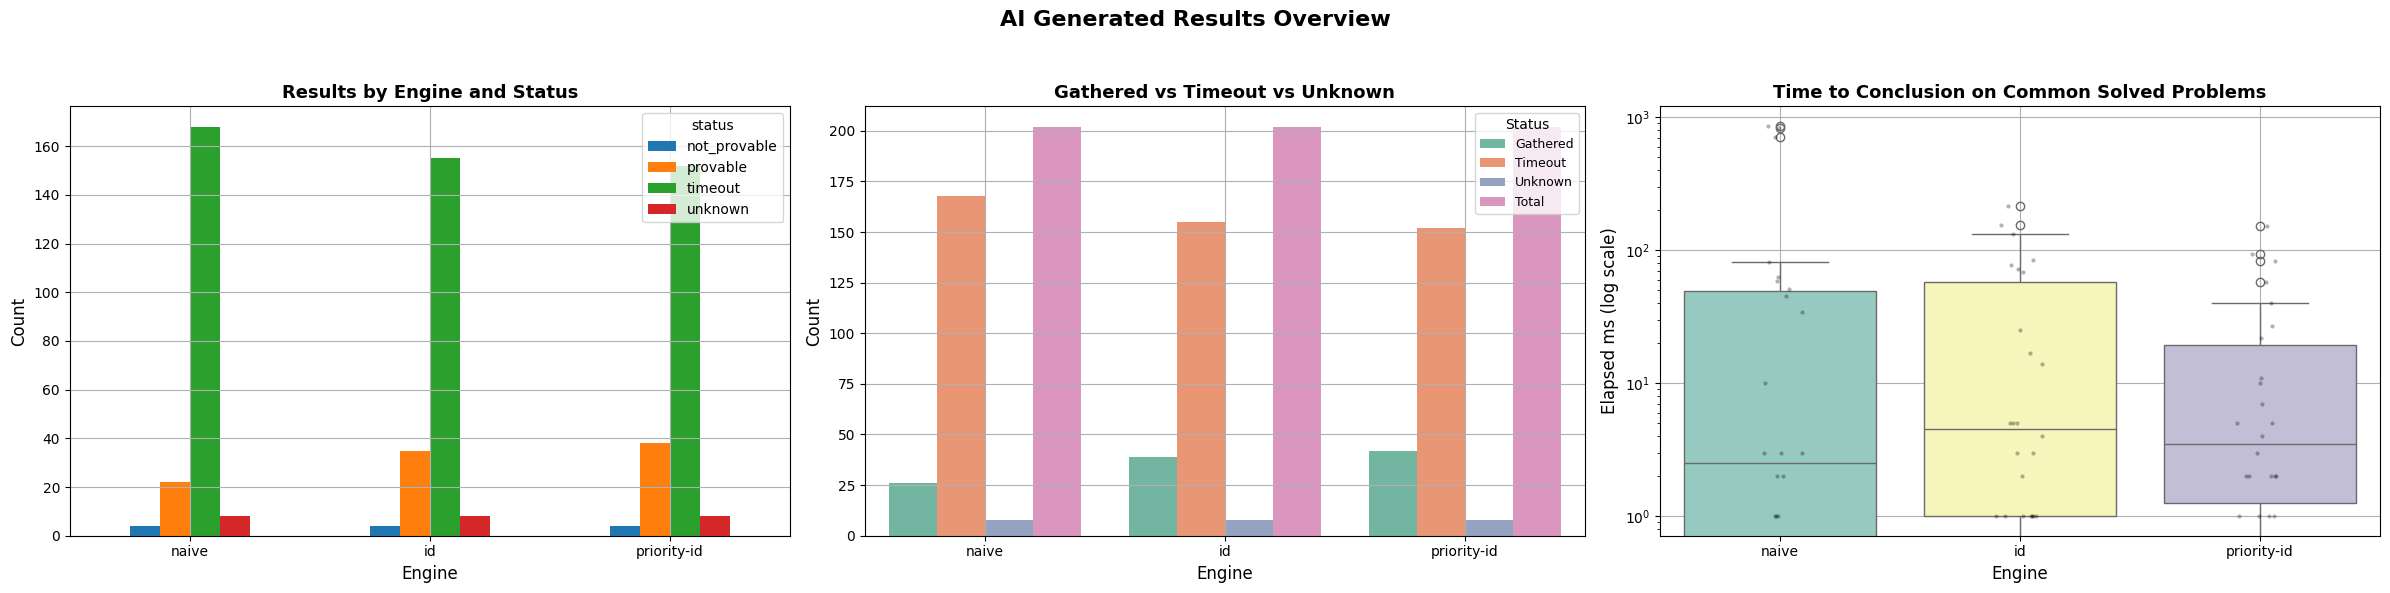


                            Output Summary                            
Output Directory: C:\Users\madel\source\repos\logic-assignment\report\figures\tabulated
Dataset: ai_generated
Files Saved:
  - ai_generated_engine_status_pivot.csv
  - ai_generated_result_type_summary.csv
  - ai_generated_common_solved_timing.csv
Figure: ../report/figures/ai_generated_overview.svg


In [167]:
# Analyze AI Generated
ai_gen_merged, ai_gen_summary, ai_gen_status_pivot, ai_gen_result_types, ai_gen_timing = analyze_dataset(
    'ai-generated-results.db',
    'ai_generated',
    'AI Generated Results'
)

Using provided dataframe:
  Merged: 2664 rows


TPTP Combined (Provable + Unprovable) Summary
     Engine  Gathered  Timeout  Unknown  Total
      naive       156      716       16    888
         id       203      669       16    888
priority-id       213      658       17    888


C:\Users\madel\AppData\Local\Temp\ipykernel_5768\1544350362.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='engine', y='elapsed_ms', palette='Set3', ax=axes[2], order=ENGINE_ORDER)


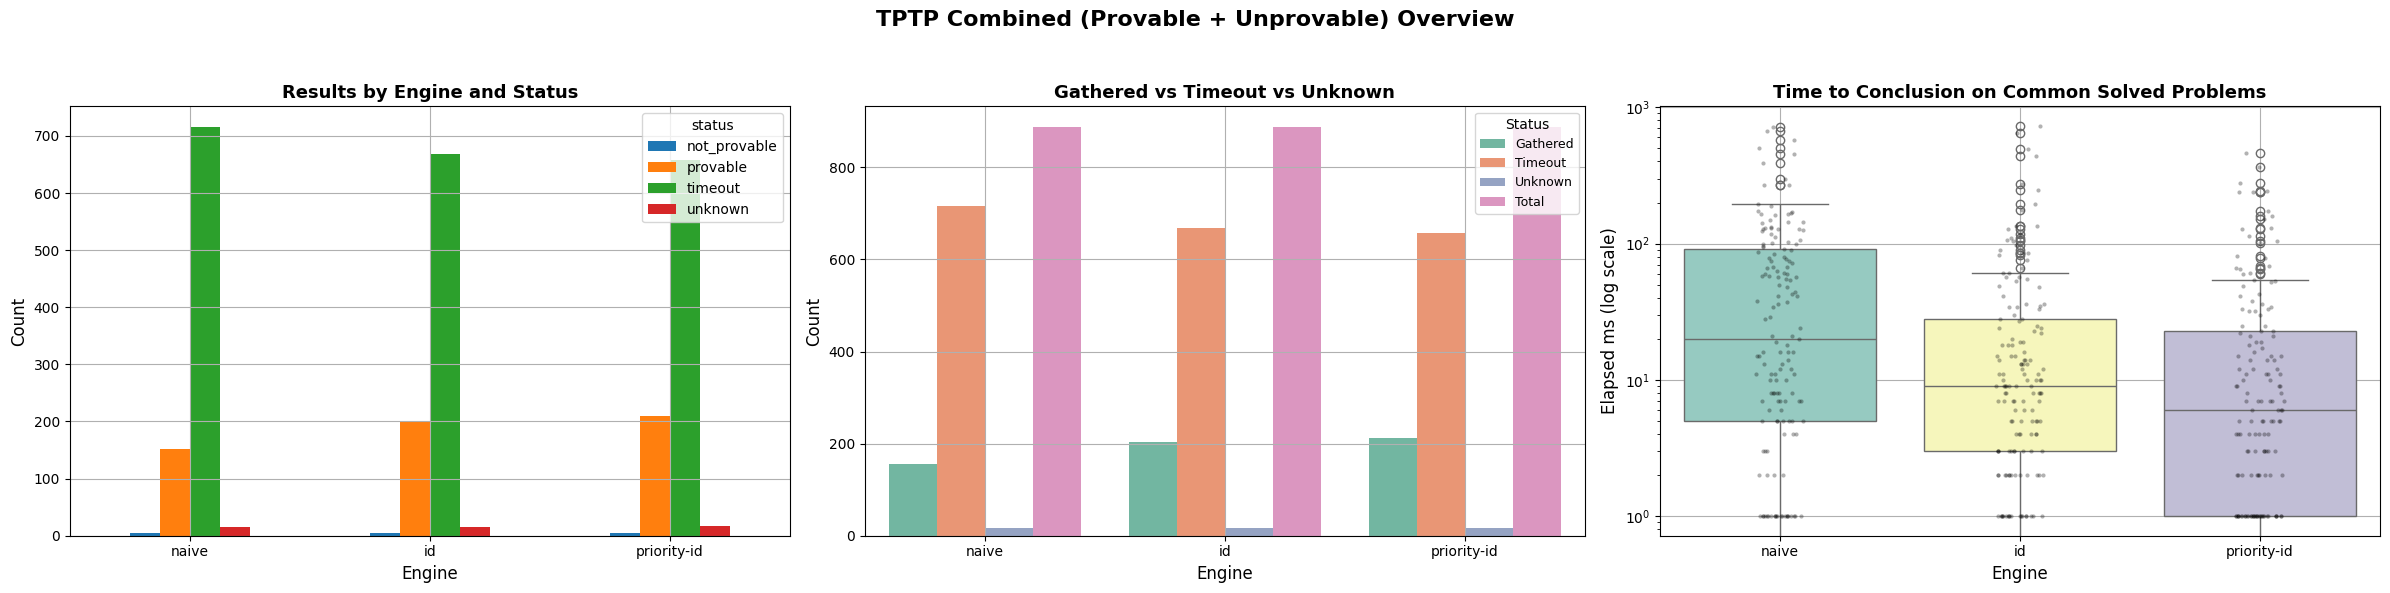


                            Output Summary                            
Output Directory: C:\Users\madel\source\repos\logic-assignment\report\figures\tabulated
Dataset: tptp_combined
Files Saved:
  - tptp_combined_engine_status_pivot.csv
  - tptp_combined_result_type_summary.csv
  - tptp_combined_common_solved_timing.csv
Figure: ../report/figures/tptp_combined_overview.svg


In [168]:
# Combine TPTP Provable and Unprovable results
tptp_combined_df = pd.concat([tptp_prov_merged, tptp_unprv_merged], ignore_index=True)

tptp_combined_merged, tptp_combined_summary, tptp_combined_status_pivot, tptp_combined_result_types, tptp_combined_timing = analyze_dataset(
    tptp_combined_df,
    'tptp_combined',
    'TPTP Combined (Provable + Unprovable)'
)